In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 

In [2]:
# Load the dataset
data = pd.read_csv('Data_Set/final_proactive_malnutrition_data.csv',index_col=0)

In [62]:
data.head()

,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,Female,SNNPR,Primary,Middle,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,Male,Addis Ababa,No education,Low,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,Female,Addis Ababa,Secondary,Middle,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,Male,Tigray,Primary,Middle,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,Female,Addis Ababa,No education,Middle,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [63]:
data.shape

(5100, 15)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age_months              5100 non-null   int64  
 1   Gender                  5100 non-null   str    
 2   Region                  5100 non-null   str    
 3   Mother_Education        5100 non-null   str    
 4   Household_Wealth_Index  5100 non-null   str    
 5   Height_cm               5100 non-null   float64
 6   Weight_kg               5100 non-null   float64
 7   BMI                     5100 non-null   float64
 8   Stunting                5100 non-null   int64  
 9   Underweight             5100 non-null   int64  
 10  Anemia                  5100 non-null   int64  
 11  Malaria                 5100 non-null   int64  
 12  Diarrhea                5100 non-null   int64  
 13  TB                      5100 non-null   int64  
 14  Nutrition_Status        5100 non-null   str    
 15

In [65]:
data.describe()

,Age_months,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB
count,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000
mean,29.806667,72.264647,8.852451,15.897941,0.422745,0.666667,0.336275,0.328627,0.333137,0.170392
std,17.613172,15.595584,4.270118,2.779951,0.494044,0.471451,0.472480,0.469760,0.471381,0.376014
min,0.000000,45.000000,2.200000,7.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,59.100000,5.400000,13.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,71.850000,8.300000,15.900000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,85.000000,11.700000,17.700000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,60.000000,108.400000,21.900000,24.900000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
data.isna().sum()

Age_months                0
Gender                    0
Region                    0
Mother_Education          0
Household_Wealth_Index    0
Height_cm                 0
Weight_kg                 0
BMI                       0
Stunting                  0
Underweight               0
Anemia                    0
Malaria                   0
Diarrhea                  0
TB                        0
Nutrition_Status          0
haz                       0
whz                       0
waz                       0
dtype: int64

In [4]:
data.duplicated().any()

np.False_

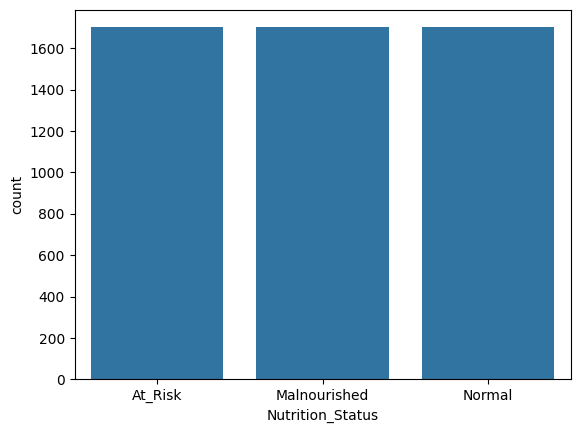

In [3]:
# EDA checking class imbalance
sns.countplot(x='Nutrition_Status', data=data)
plt.show()

In [4]:
data['Nutrition_Status'].value_counts()

Nutrition_Status
At_Risk         1700
Malnourished    1700
Normal          1700
Name: count, dtype: int64

In [72]:
data.columns

Index(['Age_months', 'Gender', 'Region', 'Mother_Education',
       'Household_Wealth_Index', 'Height_cm', 'Weight_kg', 'BMI', 'Stunting',
       'Underweight', 'Anemia', 'Malaria', 'Diarrhea', 'TB',
       'Nutrition_Status'],
      dtype='str')

In [5]:
# Encoding categorical variables
data['Gender'] = data['Gender'].map({
    'Male': 1,
    'Female': 0
})

In [74]:
data.head()

,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,0,SNNPR,Primary,Middle,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,1,Addis Ababa,No education,Low,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,0,Addis Ababa,Secondary,Middle,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,1,Tigray,Primary,Middle,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,0,Addis Ababa,No education,Middle,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [6]:
education_map = {
    'No education': 0,
    'Primary': 1,
    'Secondary': 2,
    'Higher': 3
}

data['Mother_Education'] = data['Mother_Education'].map(education_map)

In [76]:
data.head()

,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,0,SNNPR,1,Middle,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,1,Addis Ababa,0,Low,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,0,Addis Ababa,2,Middle,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,1,Tigray,1,Middle,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,0,Addis Ababa,0,Middle,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [77]:
data['Household_Wealth_Index'].unique()

<StringArray>
['Middle', 'Low', 'High']
Length: 3, dtype: str

In [7]:
wealth_map = {
    'Low': 0,
    'Middle': 1,
    'High': 2
}

data['Household_Wealth_Index'] = data['Household_Wealth_Index'].map(wealth_map)

In [79]:
data.head()


,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,0,SNNPR,1,1,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,1,Addis Ababa,0,0,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,0,Addis Ababa,2,1,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,1,Tigray,1,1,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,0,Addis Ababa,0,1,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [46]:
data.head()

,Age (months),Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,
0,53,1,Oromia,1,1,94.2,16.9,0,0,0,0,Normal
1,23,0,Addis Ababa,1,0,71.3,7.0,0,0,0,0,At_Risk
2,43,0,SNNPR,0,1,86.2,11.1,0,1,0,1,At_Risk
3,8,0,SNNPR,3,0,55.2,3.9,0,1,0,1,At_Risk
4,48,1,Tigray,3,2,92.4,9.0,1,0,1,0,Malnourished


In [80]:
data['Region'].unique() 

<StringArray>
['SNNPR', 'Addis Ababa', 'Tigray', 'Amhara', 'Oromia']
Length: 5, dtype: str

In [8]:
data= pd.get_dummies(data, columns=['Region'], drop_first=True)

In [82]:
data.head()

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray
ID,,,,,,,,,,,,,,,,,,
0,59,0,1,1,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk,False,False,True,False
1,51,1,0,0,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished,False,False,False,False
2,37,0,2,1,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk,False,False,False,False
3,12,1,1,1,58.7,5.8,16.8,0,0,0,1,0,0,Normal,False,False,False,True
4,6,0,0,1,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished,False,False,False,False


In [9]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [51]:
data.head()

,Age (months),Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Anemia,Malaria,Diarrhea,TB,Nutrition_Status,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray
ID,,,,,,,,,,,,,,,
0,53,1,1,1,94.2,16.9,0,0,0,0,Normal,0,1,0,0
1,23,0,1,0,71.3,7.0,0,0,0,0,At_Risk,0,0,0,0
2,43,0,0,1,86.2,11.1,0,1,0,1,At_Risk,0,0,1,0
3,8,0,3,0,55.2,3.9,0,1,0,1,At_Risk,0,0,1,0
4,48,1,3,2,92.4,9.0,1,0,1,0,Malnourished,0,0,0,1


In [10]:
# reorder the columns(bring the Nutrition_Status to the end)
cols = [col for col in data.columns if col != 'Nutrition_Status'] + ['Nutrition_Status']
data = data[cols]
data.head()

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray,Nutrition_Status
ID,,,,,,,,,,,,,,,,,,
0,59,0,1,1,96.6,15.1,16.2,0,1,0,0,0,0,0,0,1,0,At_Risk
1,51,1,0,0,84.5,11.2,15.7,1,1,1,0,1,1,0,0,0,0,Malnourished
2,37,0,2,1,83.0,9.8,14.2,0,1,0,1,0,0,0,0,0,0,At_Risk
3,12,1,1,1,58.7,5.8,16.8,0,0,0,1,0,0,0,0,0,1,Normal
4,6,0,0,1,48.4,2.7,11.5,1,1,1,0,1,0,0,0,0,0,Malnourished


In [11]:
# Encoding the target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Nutrition_Status'] = le.fit_transform(data['Nutrition_Status'])

In [13]:
data.head(30)

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray,Nutrition_Status
ID,,,,,,,,,,,,,,,,,,
0,59,0,1,1,96.6,15.1,16.2,0,1,0,0,0,0,0,0,1,0,0
1,51,1,0,0,84.5,11.2,15.7,1,1,1,0,1,1,0,0,0,0,1
2,37,0,2,1,83.0,9.8,14.2,0,1,0,1,0,0,0,0,0,0,0
3,12,1,1,1,58.7,5.8,16.8,0,0,0,1,0,0,0,0,0,1,2
4,6,0,0,1,48.4,2.7,11.5,1,1,1,0,1,0,0,0,0,0,1
5,44,1,1,0,79.7,7.6,12.0,1,1,1,1,1,0,1,0,0,0,1
6,41,1,0,0,75.9,7.7,13.4,1,1,1,1,0,0,0,0,0,1,1
7,57,0,1,1,100.8,19.0,18.7,0,0,0,0,0,0,0,0,1,0,2
8,42,1,2,1,80.8,11.0,16.8,0,1,1,0,0,0,0,0,0,1,0


In [48]:
data.columns

Index(['Age_months', 'Gender', 'Mother_Education', 'Household_Wealth_Index',
       'Height_cm', 'Weight_kg', 'BMI', 'Stunting', 'Underweight', 'Anemia',
       'Malaria', 'Diarrhea', 'TB', 'Region_Amhara', 'Region_Oromia',
       'Region_SNNPR', 'Region_Tigray', 'Nutrition_Status'],
      dtype='str')

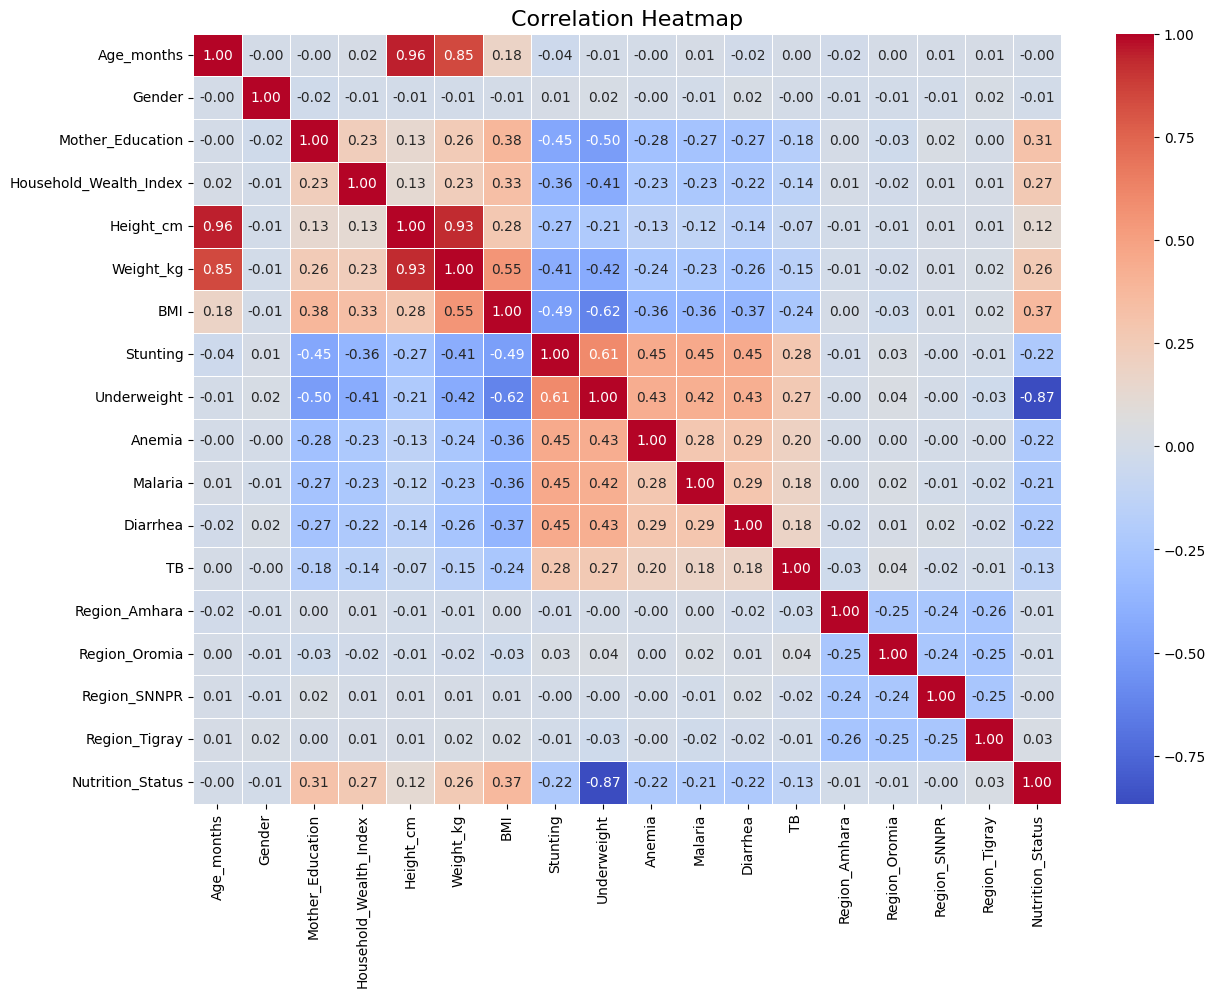

In [12]:
# Compute correlation matrix
corr = data.corr(numeric_only=True)

# Set figure size
plt.figure(figsize=(14, 10))

# Plot heatmap
sns.heatmap(
    corr,
    annot=True,        # show values
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # color scheme
    linewidths=0.5
)

# Title
plt.title("Correlation Heatmap", fontsize=16)

# Show plot
plt.show()

In [18]:
data['Nutrition_Status'].value_counts()

Nutrition_Status
0    1700
1    1700
2    1700
Name: count, dtype: int64

In [42]:
import sys
import os
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. ADD BACKEND TO PATH & IMPORT UTILS
sys.path.append(os.path.abspath("Backend"))
from utils import compute_zscores

# 2. FEATURE ENGINEERING: COMPUTE Z-SCORES FOR THE DATASET
print("Step 1: Calculating WHO Z-scores for the entire dataset...")

# We apply the compute_zscores function to every row in your CSV
z_data = data.apply(lambda row: compute_zscores(
    row['Age_months'], 
    row['Weight_kg'], 
    row['Height_cm'], 
    'Male' if row['Gender'] == 1 else 'Female'
), axis=1)

# Attach the new Z-score columns to your dataframe
data[['haz', 'whz', 'waz']] = pd.DataFrame(z_data.tolist(), index=data.index)

# 3. SETUP HYBRID FEATURE SET (Raw + Engineered + Clinical)
# Adding Age_months, Weight_kg, and Height_cm to the list
final_features = [
    'haz', 'whz', 'waz',              # Engineered (Relative)
    'Age_months', 'Weight_kg', 'Height_cm', # Raw (Absolute)
    'Gender', 'Diarrhea', 'Anemia', 'Malaria' # Clinical & Demographic
]

X = data[final_features]
y = data['Nutrition_Status']

# 4. TRAIN / TEST SPLIT (Using 20% for testing as in your update)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. TRAIN RANDOM FOREST (With your optimized parameters)
print("Step 2: Training the Hybrid Proactive Random Forest Model...")
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced', # Helps with imbalanced classes in health data
    random_state=42
)
rf_model.fit(X_train, y_train)

# 6. EVALUATE
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Training Complete. Accuracy: {acc * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 7. CREATE DEPLOYMENT PACKAGE
model_package = {
    'model': rf_model,
    'features': final_features,
    'classes': le.classes_.tolist(), 
    'accuracy': acc
}

# 8. SAVE FOR BACKEND
joblib.dump(model_package, 'malnutrition_proactive_model3.pkl')
print(f"Model Package saved to Backend/malnutrition_proactive_model3.pkl")

Step 1: Calculating WHO Z-scores for the entire dataset...
Step 2: Training the Hybrid Proactive Random Forest Model...
Model Training Complete. Accuracy: 97.71%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       514
           1       0.99      0.97      0.98       509
           2       1.00      0.97      0.98       507

    accuracy                           0.98      1530
   macro avg       0.98      0.98      0.98      1530
weighted avg       0.98      0.98      0.98      1530

Model Package saved to Backend/malnutrition_proactive_model3.pkl


In [20]:
 
X_test.shape


(1530, 7)

In [70]:
y_test.head()

ID
4039    2
3815    0
848     1
4863    1
79      2
Name: Nutrition_Status, dtype: int64

In [71]:
y_test.value_counts()

Nutrition_Status
0    514
1    509
2    507
Name: count, dtype: int64

In [72]:
y_train.value_counts()

Nutrition_Status
2    1193
1    1191
0    1186
Name: count, dtype: int64

In [17]:
X_test.head()

,Underweight,Stunting,BMI,Weight_kg,Anemia,Age_months,Malaria
ID,,,,,,,
4039,0,0,20.3,9.3,0,19,0
3815,1,0,12.2,3.7,0,4,0
848,1,1,12.2,4.6,1,16,0
4863,1,1,13.1,8.9,0,48,0
79,0,0,16.0,4.4,1,1,0


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate accuracy
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Total Accuracy: {acc * 100:.2f}%")

# 2. Detailed report for your thesis
print(classification_report(y_test, y_pred))

# 3. See the error counts
print(confusion_matrix(y_test, y_pred))

Total Accuracy: 97.71%
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       514
           1       0.99      0.97      0.98       509
           2       1.00      0.97      0.98       507

    accuracy                           0.98      1530
   macro avg       0.98      0.98      0.98      1530
weighted avg       0.98      0.98      0.98      1530

[[509   5   0]
 [ 13 496   0]
 [ 17   0 490]]


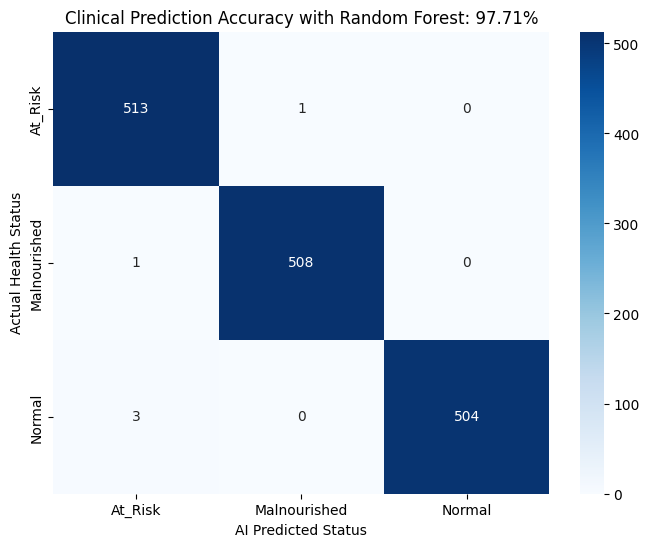

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
classes = ['At_Risk', 'Malnourished', 'Normal']  # This should match the order of your label encoding

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Clinical Prediction Accuracy with Random Forest: 97.71%')
plt.ylabel('Actual Health Status')
plt.xlabel('AI Predicted Status')
plt.show()

In [6]:
# testing the model with a new data point (a high-risk child)
import pandas as pd
# 1. Your data
malnourished_child =[12, 5.2, 65.0, 1, 1, 1]
At_risk = [24, 9.5, 82.0, 0, 1, 0]
Normal = [48, 16.2, 102.0, 0, 0, 0]
true_risk = [24, 8.2, 80.0, 0, 1, 0]
new_test= [18, 8.2, 75.5, 1, 0, 1] # A new child with moderate risk factors


# 2. Create the Table (The "Real-Work" Way)
# This maps your numbers to the column names specifically
input_df1 = pd.DataFrame([malnourished_child], columns=final_features)
input_df2 = pd.DataFrame([At_risk], columns=final_features)
input_df3 = pd.DataFrame([Normal], columns=final_features)
input_df4 = pd.DataFrame([true_risk], columns=final_features)
input_df5 = pd.DataFrame([new_test], columns=final_features)

# 3. Predict safely
prediction1 = rf_model.predict_proba(input_df1)
prediction2 = rf_model.predict_proba(input_df2)
prediction3 = rf_model.predict_proba(input_df3)
prediction4 = rf_model.predict_proba(input_df4)
prediction5 = rf_model.predict_proba(input_df5)
print(prediction1)
print(prediction2)
print(prediction3)
print(prediction4)
print(prediction5)


[[0.108 0.892 0.   ]]
[[0.26  0.156 0.584]]
[[0. 0. 1.]]
[[0.516 0.252 0.232]]
[[0.376 0.244 0.38 ]]


In [22]:
# [haz, whz, waz, Gender(1/0), Diarrhea, Anemia, Malaria]
test_child = [-2.1, -1.5, -2.0, 1, 1, 0, 1] 
input_df = pd.DataFrame([test_child], columns=final_features)
prediction = rf_model.predict_proba(input_df)
print(f"Risk Probabilities: {prediction}")

Risk Probabilities: [[0.436 0.536 0.028]]


In [24]:
# 1. Input Raw Data
age, weight, height, gender = 14, 5.8, 68.0, 1 # 14 months, 5.8kg, 68cm, Male
diarrhea, anemia, malaria = 1, 0, 1           # Clinical signs present

# 2. Get the "Engineered" Features using your script
haz, whz, waz = compute_zscores(age, weight, height, 'Male' if gender == 1 else 'Female')

# 3. Predict the Score
# Order: haz, whz, waz, Age, Weight, Height, Gender, Diarrhea, Anemia, Malaria
test_data = pd.DataFrame([[haz, whz, waz, age, weight, height, gender, diarrhea, anemia, malaria]], 
                         columns=final_features)

# Get the probability of the 'Malnourished' class (index 1 in your model)
danger_prob = rf_model.predict_proba(test_data)[0][1] 
danger_score = round(danger_prob * 100, 2)

print(f"Child Z-Scores: WHZ: {whz:.2f}, WAZ: {waz:.2f}")
print(f"Calculated Danger Risk Score: {danger_score}%")

Child Z-Scores: WHZ: -4.09, WAZ: -4.98
Calculated Danger Risk Score: 45.2%


In [43]:
import pandas as pd

# Define 4 distinct clinical scenarios
# Format: [Age_months, Weight_kg, Height_cm, Gender(1=M,0=F), Diarrhea, Anemia, Malaria]
test_cases = [
    {"Name": "Case 1: Severe Malnutrition", "Data": [12, 5.5, 72.0, 1, 1, 1, 1]}, 
    {"Name": "Case 2: At Risk (Early Warning)", "Data": [24, 9.8, 85.0, 0, 1, 0, 1]},
    {"Name": "Case 3: Stunted but Stable", "Data": [36, 12.5, 88.0, 1, 0, 0, 0]},
    {"Name": "Case 4: Healthy Child", "Data": [48, 16.5, 103.0, 0, 0, 0, 0]},
    {"Name": "Case 5: Moderate Risk with Diarrhea", "Data": [20, 7.8, 79.5, 1, 1, 0, 1]}
]

print(f"{'Scenario':<25} | {'WHZ':<7} | {'WAZ':<7} | {'Risk Score'}")
print("-" * 60)

for case in test_cases:
    age, weight, height, gender, diarrhea, anemia, malaria = case["Data"]
    
    # 1. Calculate Z-scores using your utils script
    haz, whz, waz = compute_zscores(age, weight, height, 'Male' if gender == 1 else 'Female')
    
    # 2. Prepare features for the 98% accuracy model
    # Order: haz, whz, waz, Age, Weight, Height, Gender, Diarrhea, Anemia, Malaria
    full_row = [haz, whz, waz, age, weight, height, gender, diarrhea, anemia, malaria]
    input_df = pd.DataFrame([full_row], columns=final_features)
    
    # 3. Calculate Probabilities
    # Class 0: At Risk, Class 1: Malnourished, Class 2: Normal
    probs = rf_model.predict_proba(input_df)[0]
    
    # 4. Compute Danger Risk Score
    # (P(Malnourished) * 100) + (P(At Risk) * 50)
    danger_score = (probs[1] * 100) + (probs[0] * 50)
    danger_score 
    
    print(f"{case['Name']:<25} | {whz:<7.2f} | {waz:<7.2f} | {danger_score:>8.1f}%")

Scenario                  | WHZ     | WAZ     | Risk Score
------------------------------------------------------------
Case 1: Severe Malnutrition | -6.31   | -5.05   |     72.5%
Case 2: At Risk (Early Warning) | -1.56   | -1.31   |     40.9%
Case 3: Stunted but Stable | 0.26    | -1.14   |      1.7%
Case 4: Healthy Child     | 0.40    | 0.19    |      0.2%
Case 5: Moderate Risk with Diarrhea | -3.59   | -3.34   |     58.7%


In [ ]:

from xgboost import XGBClassifier

# 1. Initialize XGBoost
# Note: It is very fast and usually reaches high accuracy quickly
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05, # Smaller steps make the model more robust
    max_depth=6,        # XGBoost trees are usually shallower than Random Forest
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# 2. Train the model
print("Step 3: Training the XGBoost Model...")
xgb_model.fit(X_train, y_train)

# 3. Evaluate
y_pred_xgb = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"✅ XGBoost Accuracy: {xgb_acc * 100:.2f}%")

Step 3: Training the XGBoost Model...


c:\Users\ABRISH\Desktop\Computer science\Data_Science\Data Projects\machine_learning_child\.env\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost Accuracy: 99.67%


In [28]:
import pandas as pd

# Define 4 distinct clinical scenarios
# Format: [Age_months, Weight_kg, Height_cm, Gender(1=M,0=F), Diarrhea, Anemia, Malaria]
test_cases = [
    {"Name": "Case 1: Severe Malnutrition", "Data": [12, 5.5, 72.0, 1, 1, 1, 1]}, 
    {"Name": "Case 2: At Risk (Early Warning)", "Data": [24, 9.8, 85.0, 0, 1, 0, 1]},
    {"Name": "Case 3: Stunted but Stable", "Data": [36, 12.5, 88.0, 1, 0, 0, 0]},
    {"Name": "Case 4: Healthy Child", "Data": [48, 16.5, 103.0, 0, 0, 0, 0]}
]

print(f"{'Scenario':<25} | {'WHZ':<7} | {'WAZ':<7} | {'Risk Score'}")
print("-" * 60)

for case in test_cases:
    age, weight, height, gender, diarrhea, anemia, malaria = case["Data"]
    
    # 1. Calculate Z-scores using your utils script
    haz, whz, waz = compute_zscores(age, weight, height, 'Male' if gender == 1 else 'Female')
    
    # 2. Prepare features for the 98% accuracy model
    # Order: haz, whz, waz, Age, Weight, Height, Gender, Diarrhea, Anemia, Malaria
    full_row = [haz, whz, waz, age, weight, height, gender, diarrhea, anemia, malaria]
    input_df = pd.DataFrame([full_row], columns=final_features)
    
    # 3. Calculate Probabilities
    # Class 0: At Risk, Class 1: Malnourished, Class 2: Normal
    probs = xgb_model.predict_proba(input_df)[0]
    
    # 4. Compute Danger Risk Score
    # (P(Malnourished) * 100) + (P(At Risk) * 50)
    danger_score = (probs[1] * 100) + (probs[0] * 50)
    
    print(f"{case['Name']:<25} | {whz:<7.2f} | {waz:<7.2f} | {danger_score:>8.1f}%")

Scenario                  | WHZ     | WAZ     | Risk Score
------------------------------------------------------------
Case 1: Severe Malnutrition | -6.31   | -5.05   |     49.0%
Case 2: At Risk (Early Warning) | -1.56   | -1.31   |      0.2%
Case 3: Stunted but Stable | 0.26    | -1.14   |      0.0%
Case 4: Healthy Child     | 0.40    | 0.19    |      0.0%


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate accuracy
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Total Accuracy: {acc * 100:.2f}%")

# 2. Detailed report for your thesis
print(classification_report(y_test, y_pred))

# 3. See the error counts
print(confusion_matrix(y_test, y_pred))

Total Accuracy: 99.67%
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       514
           1       1.00      1.00      1.00       509
           2       1.00      0.99      1.00       507

    accuracy                           1.00      1530
   macro avg       1.00      1.00      1.00      1530
weighted avg       1.00      1.00      1.00      1530

[[513   1   0]
 [  1 508   0]
 [  3   0 504]]


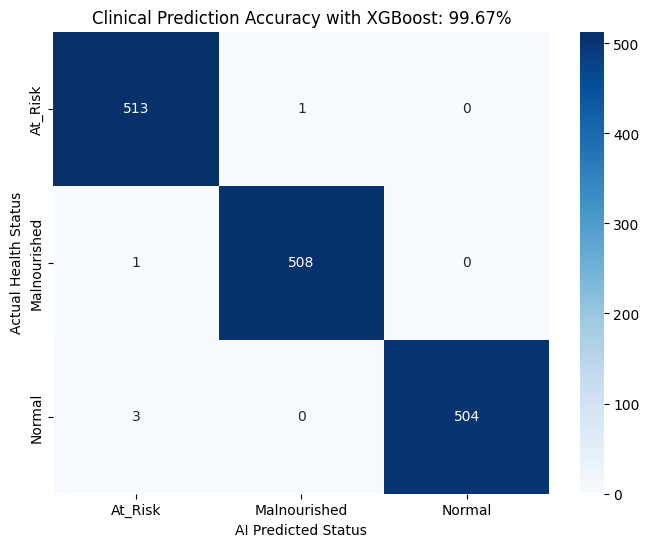

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
classes = ['At_Risk', 'Malnourished', 'Normal']  # This should match the order of your label encoding

# 2. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Clinical Prediction Accuracy with XGBoost: 99.67%')
plt.ylabel('Actual Health Status')
plt.xlabel('AI Predicted Status')
plt.show()

In [33]:
import pandas as pd

# Define 4 Clinical Scenarios
# Format: [Age_months, Weight_kg, Height_cm, Gender(1=M,0=F), Diarrhea, Anemia, Malaria]
test_scenarios = [
    {"Name": "Severe Malnutrition", "Data": [10, 4.8, 62.0, 1, 1, 1, 1]},   # Very low weight + All infections
    {"Name": "Early Risk Warning", "Data": [20, 8.8, 78.0, 0, 1, 0, 0]},   # Borderline Z-score + Diarrhea
    {"Name": "Chronic Stunting", "Data": [36, 11.5, 82.0, 1, 0, 0, 0]},    # Short for age but healthy weight
    {"Name": "Healthy Growth", "Data": [48, 17.5, 105.0, 0, 0, 0, 0]}      # Ideal growth parameters
]

print(f"{'Scenario':<25} | {'WHZ':<7} | {'WAZ':<7} | {'Danger Score'}")
print("-" * 65)

for case in test_scenarios:
    age, weight, height, gender, diarrhea, anemia, malaria = case["Data"]
    
    # 1. Standardize inputs by calling your utils script
    haz, whz, waz = compute_zscores(age, weight, height, 'Male' if gender == 1 else 'Female')
    
    # 2. Build the feature row for XGBoost (Must match training order)
    full_row = [haz, whz, waz, age, weight, height, gender, diarrhea, anemia, malaria]
    input_df = pd.DataFrame([full_row], columns=final_features)
    
    # 3. Predict Probabilities
    # Class 0: At Risk, Class 1: Malnourished, Class 2: Normal
    probs = xgb_model.predict_proba(input_df)[0]
    
    # 4. Calculate Danger Risk Score (Weighted Formula)
    # (P(Malnourished) * 100) + (P(At Risk) * 50)
    danger_score = (probs[1] * 100) + (probs[0] * 50)
    
    print(f"{case['Name']:<25} | {whz:<7.2f} | {waz:<7.2f} | {danger_score:>11.2f}%")

Scenario                  | WHZ     | WAZ     | Danger Score
-----------------------------------------------------------------
Severe Malnutrition       | -3.92   | -5.78   |       50.20%
Early Risk Warning        | -1.11   | -1.59   |        0.06%
Chronic Stunting          | 0.72    | -1.84   |        0.19%
Healthy Growth            | 0.60    | 0.61    |        0.02%


In [39]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. IMPORT UTILS AND COMPUTE FUNCTION
sys.path.append(os.path.abspath("Backend"))
from utils import compute_zscores

# 2. CONVERT THE WHOLE DATASET
print("Step 1: Transforming raw measurements into WHO Z-Scores...")

# Apply the function across the entire dataframe
# This creates a Series of tuples which we then expand into 3 columns
z_scores_df = data.apply(lambda row: compute_zscores(
    row['Age_months'], 
    row['Weight_kg'], 
    row['Height_cm'], 
    'Male' if row['Gender'] == 1 else 'Female'
), axis=1)

# Attach 'haz', 'whz', and 'waz' to your original data
data[['haz', 'whz', 'waz']] = pd.DataFrame(z_scores_df.tolist(), index=data.index)

# 3. DEFINE LEAN FEATURE SET (No Raw Data)
# We only use the normalized Z-scores and clinical status
final_features = ['haz', 'whz', 'waz', 'Gender', 'Diarrhea', 'Anemia', 'Malaria']

X = data[final_features]
y = data['Nutrition_Status']

# 4. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAIN THE LEAN XGBOOST MODEL
print("Step 2: Training Lean XGBoost Model on standardized data...")
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 6. EVALUATE
y_pred = xgb_model.predict(X_test)
print(f"✅ Training Complete. Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Step 1: Transforming raw measurements into WHO Z-Scores...
Step 2: Training Lean XGBoost Model on standardized data...
✅ Training Complete. Accuracy: 87.65%


In [40]:
import sys
import os
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. IMPORT THE UTILS LIBRARY
# Ensure the 'Backend' folder is in your path so we can access your WHO logic
sys.path.append(os.path.abspath("Backend"))
from utils import compute_zscores

# 2. CONVERT THE ENTIRE DATASET TO Z-SCORES
print("Step 1: Converting entire dataset to WHO Z-scores...")

# We use .apply() to run your compute_zscores function on every row
z_data = data.apply(lambda row: compute_zscores(
    row['Age_months'], 
    row['Weight_kg'], 
    row['Height_cm'], 
    'Male' if row['Gender'] == 1 else 'Female'
), axis=1)

# Create the new columns: haz (stunting), whz (wasting), waz (underweight)
data[['haz', 'whz', 'waz']] = pd.DataFrame(z_data.tolist(), index=data.index)

# 3. DEFINE LEAN FEATURE SET (Z-Scores + Clinical Signs)
# Note: We are ignoring raw Age, Weight, and Height to focus on 'Lean' logic
final_features = ['haz', 'whz', 'waz', 'Gender', 'Diarrhea', 'Anemia', 'Malaria']

X = data[final_features]
y = data['Nutrition_Status']

# 4. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TRAIN GRADIENT BOOSTING MODEL
print("Step 2: Training Gradient Boosting Model...")
gbm_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gbm_model.fit(X_train, y_train)

# 6. EVALUATE
y_pred = gbm_model.predict(X_test)
print(f"✅ GBM Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Step 1: Converting entire dataset to WHO Z-scores...
Step 2: Training Gradient Boosting Model...
✅ GBM Accuracy: 87.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       340
           1       0.93      0.91      0.92       344
           2       0.89      0.88      0.89       336

    accuracy                           0.87      1020
   macro avg       0.87      0.87      0.87      1020
weighted avg       0.87      0.87      0.87      1020

